---
着ない羽織があるなら持ってこい\
吹かない風があるなら持ってこい\
飛行しない雲があるなら持ってこい\
(夏井いつき)

**解析できないデータがあるなら持ってこい**

---

# scikit-learnの俯瞰と一連の流れのおさらい
簡単な機械学習アプリケーションを通してscikit-learnの主要機能とモデルを確認する

ここでは、最も一般的なデータであるiris(アヤメ分類)を用い、最も基本的な手法(k-近傍法)で学習を行うことで、scikit-learnについて俯瞰する

本テキストでは、簡単なモデルを比較の基準として使い、学習・評価・改善の一連の流れを確認する
- モデルを複雑にする前に、データ分割、前処理、評価指標が適切かを確かめる


# アイリスのクラス分類
アヤメの種類を予測する\
そのために、種類が分かっているアイリスの測定値を用いて機械学習モデルを構築する

setosa, versicolor, virginicaの３種類に分類
（教師あり学習、クラス分類）

<img src = 'http://class.west.sd.keio.ac.jp/dataai/scilearn/iris_petal_sepal.png' width = "30%">

## irisデータの読み込み

必要なライブラリの読み込み

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

irisデータセットの読み込み
（3種類のアイリスの花について、花弁の長さと幅、がくの長さと幅を測定した結果）

In [2]:
from sklearn.datasets import load_iris
iris_dataset = load_iris()

load_irisが返すirisオブジェクトは辞書型に似たオブジェクトで、キーと値を持つ

In [3]:
iris_dataset.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

キー DESCR の値はデータセットの簡単な説明（description）

In [4]:
print(iris_dataset['DESCR'][:200] + '\n...')

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attribu
...


キー target_names に対応する値は予測する花の種類

In [5]:
print('Target names: {}'.format(iris_dataset['target_names']))

Target names: ['setosa' 'versicolor' 'virginica']


キー feature_names に対応する値は、それぞれの特徴量の説明

In [6]:
print('Feature names: {}'.format(iris_dataset['feature_names']))

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


データ本体は、targetとdataフィールドに格納されている

dataには、がくの長さ、がくの幅、花弁の長さ、花弁の幅がNumpy配列として格納されている

In [7]:
type(iris_dataset['data'])

numpy.ndarray

配列dataの各行は個々の花、列は個々の花に対して行われた４つの測定に対応

In [8]:
iris_dataset['data'].shape

(150, 4)

配列には150の花の測定結果が格納されている\
最初の５つのサンプルを見る

In [9]:
iris_dataset['data'][:5]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

配列targetには、測定された個々の花の種類がNumpy配列として格納されている

In [10]:
type(iris_dataset['target'])

numpy.ndarray

targetは1次元配列で、個々の花に1つのエントリが対応する

In [11]:
iris_dataset['target'].shape

(150,)

花の種類は0から2までの整数としてエンコードされている\
0：setosa, 1：versicolor, 2：virginica

In [12]:
iris_dataset['target']

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

訓練データとテストデータに分割する

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(iris_dataset['data'], iris_dataset['target'], stratify=iris_dataset['target'], random_state=0)

In [14]:
print('X_train shape: {}'.format(X_train.shape))
print('y_train shape: {}'.format(y_train.shape))
print('X_test shape: {}'.format(X_test.shape))
print('y_test shape: {}'.format(y_test.shape))

X_train shape: (112, 4)
y_train shape: (112,)
X_test shape: (38, 4)
y_test shape: (38,)


scikit-learnでは、データを大文字のX、ラベルを小文字のyで表すのが一般的\
train_test_splitによって112の訓練データと38のテストデータに分割された

## データの観察

機械学習モデルを構築する前に、データを観察することが大切

**散布図**による可視化  
ここでは、全ての特徴量の組み合わせをプロットする**ペアプロット**を用いる

代表的なパラメータは次の通り
- c: マーカのcolor
- s: マーカのサイズ
- marker: マーカの形でデフォルトは'.'
- alpha: 図の点の透明度
- figsize: 図のサイズ
- grid: Trueでグリッドを表示
- hist_kwds: hist関数に渡され、ヒストグラムのbins（棒の数）を指定する

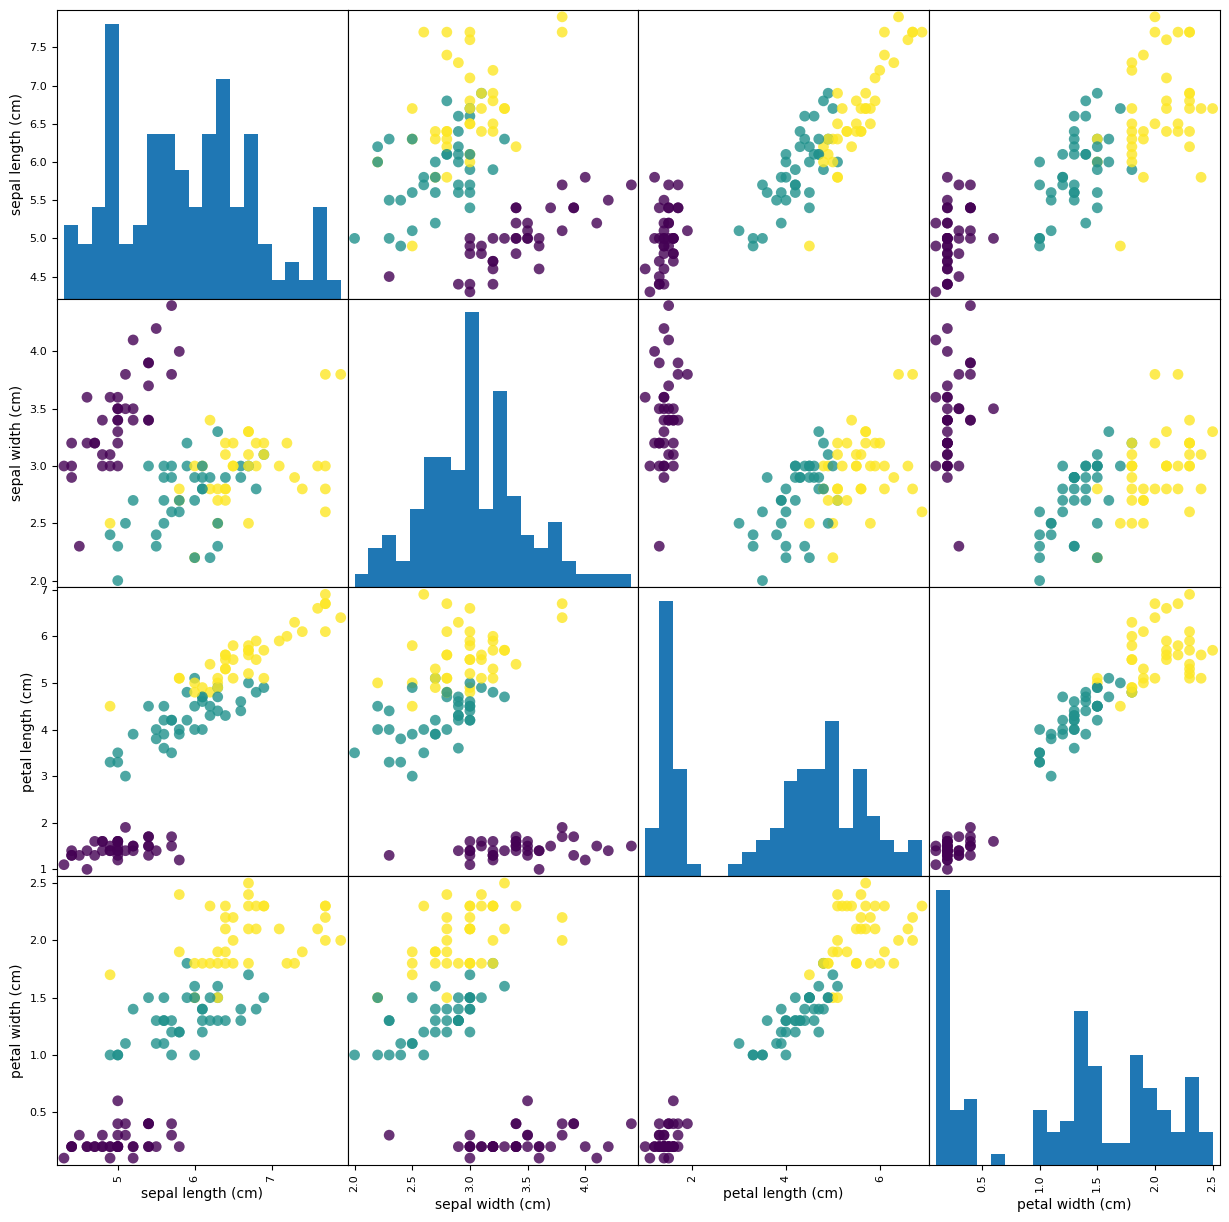

In [15]:
iris_dataframe = pd.DataFrame(X_train, columns=iris_dataset.feature_names)
grr = pd.plotting.scatter_matrix(iris_dataframe, c=y_train, figsize=(15,15), marker='o', hist_kwds={'bins':20}, s=60, alpha=.8)

３つのクラスは花弁とがくの測定結果で分離していることが分かる
つまり、うまく分類できるように機械学習モデルを訓練することができる可能性が高いことを意味する

# k-近傍法

実際に機械学習モデルを構築してみる  
ここではk-近傍法(k-NearestNeighbors)によるクラス分類を行う

k-NNは、新しい点に最も近いk個の点を訓練セットから探し、これらの多数決で新しいデータのラベルを決定する方法である

その動作の仕組みを様々にビジュアライズしたサイトがあるので確認すると良い

距離を使う方法なので、特徴量の単位や桁数が異なる場合は標準化などを検討する
- `Pipeline` を用いると、標準化を交差検証の訓練側だけで学習できる
- 多数決の比較対象には、最頻クラスを返す `DummyClassifier` などの単純な基準も用意する


<img src = 'http://class.west.sd.keio.ac.jp/dataai/scilearn/knn.png' width = "50%">

k-近傍法アルゴリズムはneighborsモジュールのKNeighborsClassifierクラスに実装されている\
モデルを使う前に、クラスのインスタンスを作成してオブジェクトを作る\
今回は k = 1とする  

In [16]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=1)

knnオブジェクトは、訓練データからモデルを構築する際に用いられるアルゴリズムと、新たなデータポイントに対する予測のためのアルゴリズムをカプセル化している\
訓練セットからモデルを構築するには、knnオブジェクトのfitメソッドを呼び出す

In [17]:
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

## 予測

構築したモデルを用いてラベルが分かっていない新たなデータの予測をしてみる\
がくの長さと幅、花弁の長さと幅をNumpy配列に格納し、knnオブジェクトのpredictメソッドを呼び出す

In [18]:
#新たなデータを格納
X_new = np.array([[5, 2.9, 1, 0.2]])  #scikit-learnは常に2次元Numpy配列の入力を前提としているため
#予測を行う
prediction = knn.predict(X_new)
#結果を表示
print('Prediction: {}'.format(prediction))
print('Predicted target name: {}'.format(iris_dataset['target_names'][prediction]))

Prediction: [0]
Predicted target name: ['setosa']


## モデル評価

先ほど作ったテストデータのそれぞれのアイリスに対して予測を行う

In [19]:
y_pred = knn.predict(X_test)
y_pred

array([0, 0, 0, 0, 1, 1, 1, 0, 1, 2, 2, 2, 1, 2, 1, 0, 0, 2, 0, 1, 2, 1,
       1, 0, 1, 0, 0, 1, 2, 1, 0, 1, 2, 2, 0, 1, 2, 2])

予測結果を正解のラベルと比較して精度を計算  
knnオブジェクトのscoreメソッドを用いる

In [20]:
knn.score(X_test, y_test)

0.9736842105263158

# サンプルデータセット
以下様々な機械学習アルゴリズムを紹介していくが、その際にいくつかのデータセットを用いるので、それらについて簡単に説明する

まず、2クラス分類データセットとして、forgeデータセットを、回帰分析としてwaveデータセットを合成する\
これらは、アルゴリズム的に機械合成されたデータである

またより現実的なデータとして、先ほど示したアイリスの他、ウィスコンシン乳癌データ、ボストン住宅データを利用する

In [21]:
!pip install mglearn
import mglearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 26.1 MB/s eta 0:00:00


make_forgeによりデータを合成する

X.shape:(26, 2)


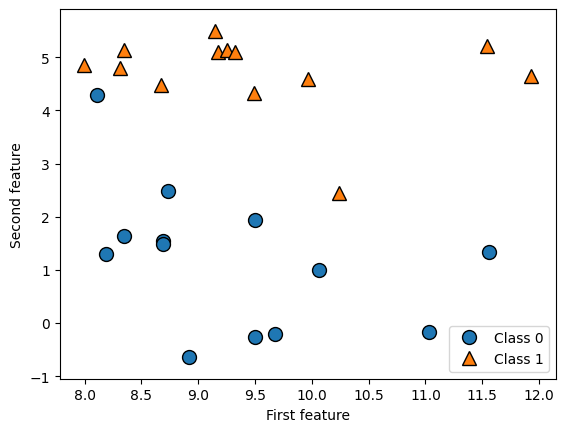

In [22]:
# データセットの生成
X, y = mglearn.datasets.make_forge()
# プロット
mglearn.discrete_scatter(X[:, 0], X[:, 1], y)
plt.legend(['Class 0', 'Class 1'], loc=4)
plt.xlabel('First feature')
plt.ylabel('Second feature')
print('X.shape:{}'.format(X.shape))

回帰アルゴリズムでは、waveデータセットを合成して用いる

Text(0, 0.5, 'Target')

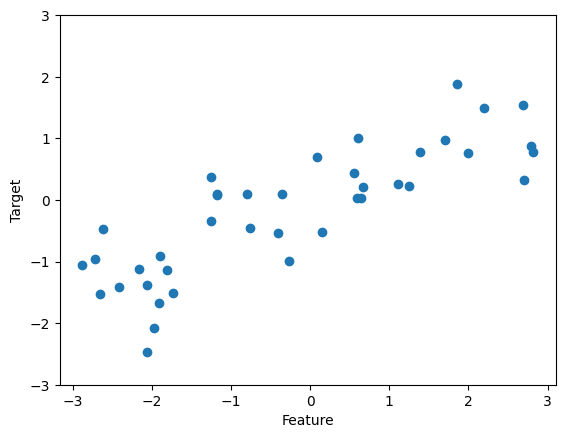

In [23]:
X, y = mglearn.datasets.make_wave(n_samples=40)
plt.plot(X, y, 'o')
plt.ylim(-3, 3)
plt.xlabel('Feature')
plt.ylabel('Target')

これらの小さい合成データセットの他に、scikit-learnに含まれている2つの実問題から取ったデータセットを用いる

１つ目は、ウィスコンシン乳癌データセットで、癌の腫瘍に良性(benign)か悪性(malignant)かのラベルがつけられている

In [24]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
cancer.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [25]:
print("Shape of cancer data:", cancer.data.shape)
print("Sample counts per class:", {n: v for n, v in zip(cancer.target_names, np.bincount(cancer.target))})

Shape of cancer data: (569, 30)
Sample counts per class: {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}


30の特徴量を持つ569のデータポイントで構成される
- そのうち212が悪性、357が良性

２つ目は、お馴染みboston housingデータセットである

すでに述べた通り、倫理上の問題がありscikit-learnからは削除された

13の特徴量を持つデータであるが、これらの積も特徴量として考える（特徴量エンジニアリング）

In [26]:
X, y = mglearn.datasets.load_extended_boston()
X.shape

(506, 104)

# 教師あり学習

## 教師あり学習について

- クラス分類　…クラスラベルを予測
 - ２クラス分類
 - 多クラス分類
- 回帰　…連続値を予測

## k-近傍法
k-近傍法は最も単純な学習アルゴリズムと言われる\
forgeデータセットに対するクラス分類の例を示す

k = 1 の場合の例

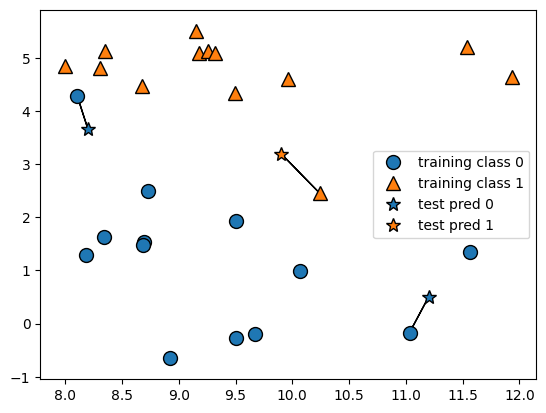

In [27]:
mglearn.plots.plot_knn_classification(n_neighbors=1)

k = 3 の場合の例

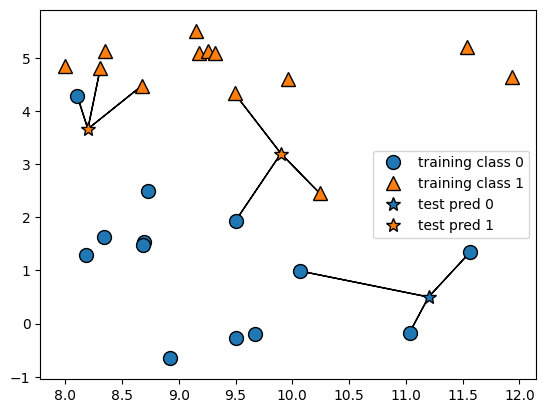

In [28]:
mglearn.plots.plot_knn_classification(n_neighbors=3)

**例題**：forgeデータを訓練セットとテストセットに分割し、k-近傍法アルゴリズムを適用してモデルの汎化性能（精度）を評価せよ\
random_state = 0, k = 3

In [29]:
# 解
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
X, y = mglearn.datasets.make_forge()
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
clf = KNeighborsClassifier(n_neighbors=3)
clf.fit(X_train, y_train)
print("Test set predictions:", clf.predict(X_test))
print("Test set accuracy: {:.2f}".format(clf.score(X_test, y_test)))

Test set predictions: [1 0 1 0 1 0 0]
Test set accuracy: 0.86


kの値を変化させる\
多くの近傍点を考慮するほど複雑度が低いモデルに対応する

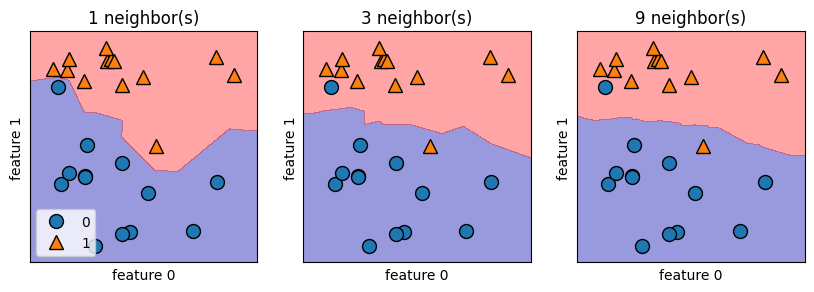

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for n_neighbors, ax in zip([1, 3, 9], axes):
  # the fit method returns the object self, so we can instantiate
  # and fit in one line
  clf = KNeighborsClassifier(n_neighbors=n_neighbors).fit(X, y)
  mglearn.plots.plot_2d_separator(clf, X, fill=True, eps=0.5, ax=ax, alpha=.4)
  mglearn.discrete_scatter(X[:, 0], X[:, 1], y, ax=ax)
  ax.set_title("{} neighbor(s)".format(n_neighbors))
  ax.set_xlabel("feature 0")
  ax.set_ylabel("feature 1")
axes[0].legend(loc=3)

## 線形回帰

既に学習済みなので、シンプルに済ませる

w[0]: 0.393906  b: -0.031804


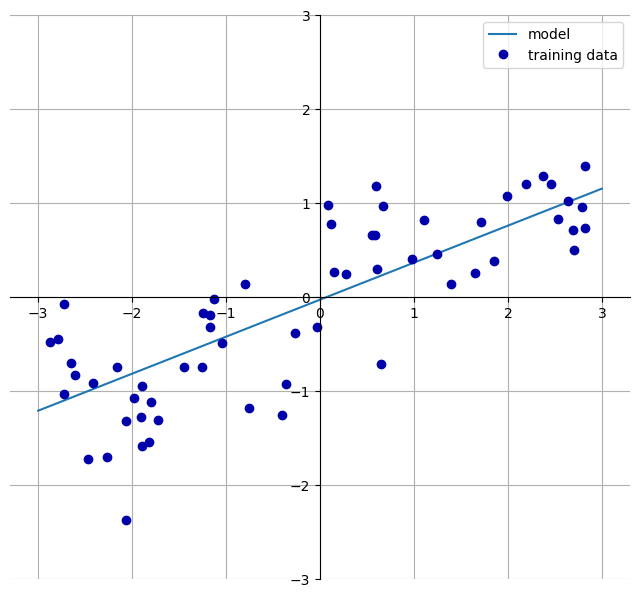

In [31]:
mglearn.plots.plot_linear_regression_wave()

In [32]:
from sklearn.linear_model import LinearRegression
X, y = mglearn.datasets.make_wave(n_samples = 60)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# モデルを適用
lr = LinearRegression().fit(X_train, y_train)

# 傾きを表すパラメータである重み（係数）はcoef_属性、切片はintercept_属性に格納
print("lr.coef_:", lr.coef_)
print("lr.intercept_:", lr.intercept_)

lr.coef_: [0.39390555]
lr.intercept_: -0.031804343026759746


In [33]:
print('Training set score: {:.2f}'.format(lr.score(X_train, y_train)))
print('Test set score: {:.2f}'.format(lr.score(X_test, y_test)))

Training set score: 0.67
Test set score: 0.66


精度はよくないが、訓練データとテストデータに対する値が非常に近いことから、過剰適合ではなく適合不足であると考えられる
- つまり、この問題のモデルとしては線形回帰は適していない、ということになる
このような1次元データセットでは過剰適合の危険は少ないが、高次元になる（データセットが多くの特徴量を持つ）と過剰適合の可能性が高まる

次に、より複雑なデータセットに対する挙動を見てみる

**例題**: boston_housingのデータセットを読み込み、訓練セットとテストセットに分割し、線形回帰モデルを作り、汎化性能を評価せよ

In [34]:
X, y = mglearn.datasets.load_extended_boston()
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
lr = LinearRegression().fit(X_train, y_train)
print("Training set score: {:.2f}".format(lr.score(X_train, y_train)))
print("Test set score: {:.2f}".format(lr.score(X_test, y_test)))

Training set score: 0.95
Test set score: 0.61


このように、訓練セットとテストセットで性能が大きく異なるのは、過剰適合が起きている証拠である\
モデルの複雑度を制御できる線形回帰として、リッジ回帰やLassoがあるが、ここでは特に触れない

## 決定木

決定木はクラス分類や回帰タスクに広く用いられているモデルである

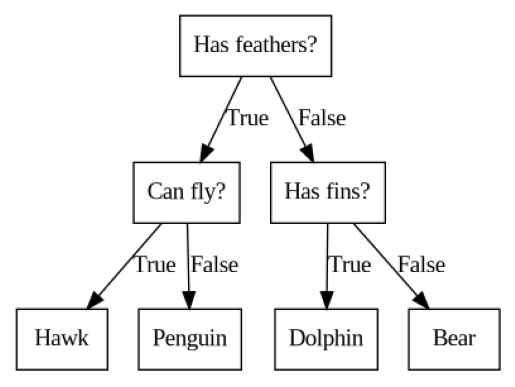

In [35]:
mglearn.plots.plot_animal_tree()

two_moonsデータセットを用いて決定木の構築過程を見る

決定木における学習とは、最も早く正解にたどり着けるような一連のYes/No型の質問の学習である  
- まず、目的変数に対して最も情報量が多い（＝よく分割する）テストを選択する
- ここでは、x[1] <= 0.0596 が選ばれた  

このプロセスを個々の領域に対して再帰的に繰り返すことで、２分木による決定木が得られる

データの再帰分割は、一つの領域に一つのクラス（または回帰値）しか含まれなくなるまで繰り返される(これは変更できる)

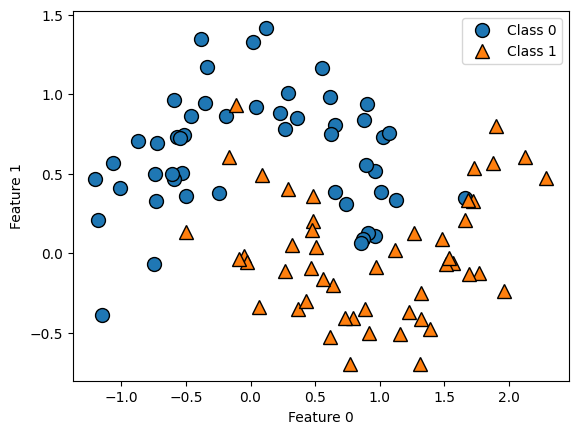

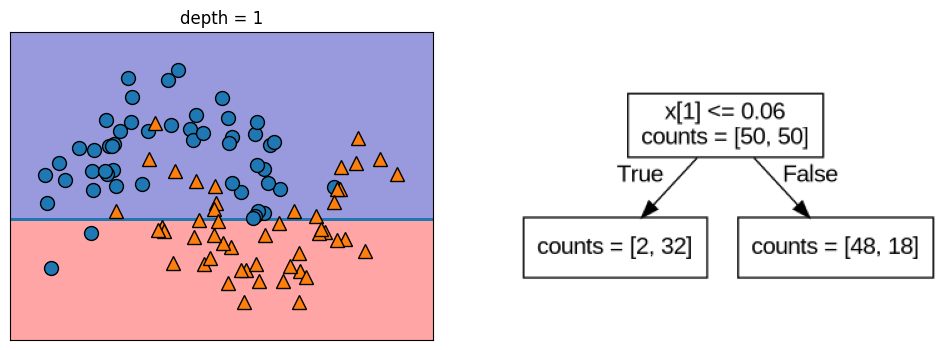

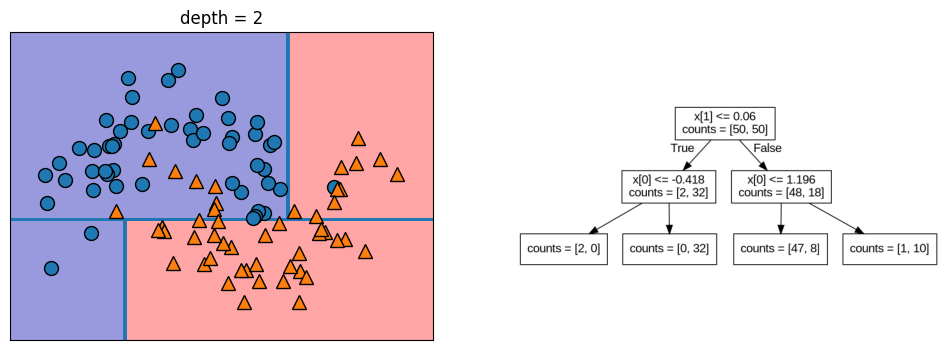

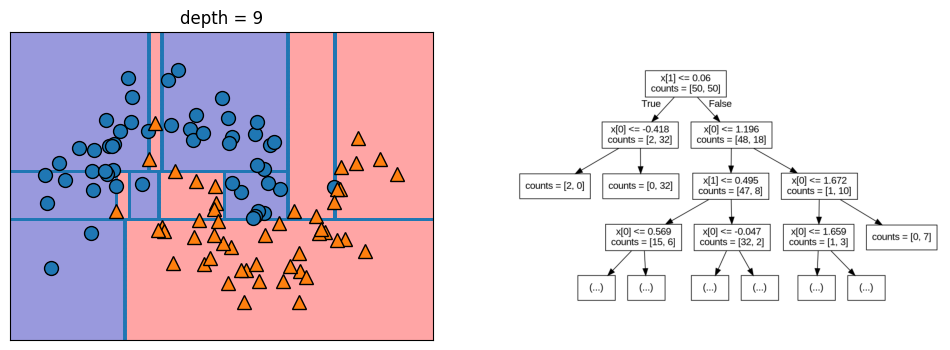

In [36]:
mglearn.plots.plot_tree_progressive()

cancerデータセットを用いて完全な木を構築してみる

In [37]:
from sklearn.tree import DecisionTreeClassifier
cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, stratify=cancer.target, random_state=42)
tree = DecisionTreeClassifier(random_state = 0)
tree.fit(X_train, y_train)
print('Accuracy on training set: {:.3f}'.format(tree.score(X_train, y_train)))
print('Accuracy on test set: {:.3f}'.format(tree.score(X_test, y_test)))

Accuracy on training set: 1.000
Accuracy on test set: 0.937


訓練セットに対する精度は100％、テストセットに対する精度は94％程度となった
- 決定木の深さに制約を与えないと、決定木はいくらでも深く複雑になり、新しいデータに対する汎化性能が低くなる
- そこで、木が完全に訓練データに適合する前に木の成長を止めてみる
- ここでは max_depth = 4（質問の列は４つまでということ）とする

In [38]:
tree = DecisionTreeClassifier(max_depth=4, random_state=0)
tree.fit(X_train, y_train)

print("Accuracy on training set: {:.3f}".format(tree.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(tree.score(X_test, y_test)))

Accuracy on training set: 0.988
Accuracy on test set: 0.951


## ランダムフォレスト

ランダムフォレストをtwo_moonsデータセットに適用してみる

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=100, noise=0.25, random_state=3)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

forest = RandomForestClassifier(n_estimators=5, random_state=2)
forest.fit(X_train, y_train)

RandomForestClassifier(n_estimators=5, random_state=2)

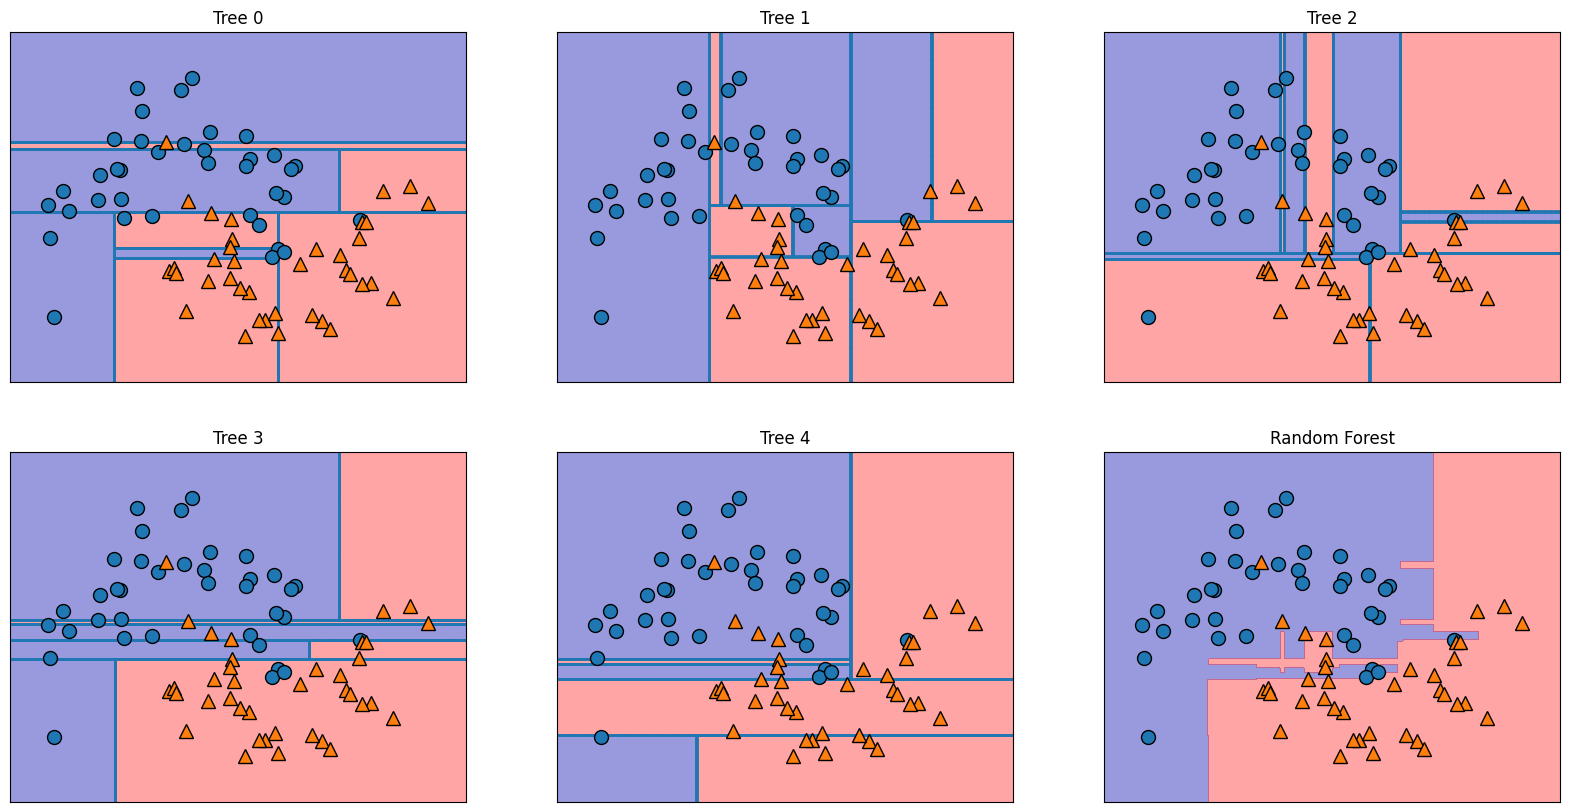

In [40]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
for i, (ax, tree) in enumerate(zip(axes.ravel(), forest.estimators_)):
  ax.set_title('Tree {}'.format(i))
  mglearn.plots.plot_tree_partition(X_train, y_train, tree, ax=ax)
mglearn.plots.plot_2d_separator(forest, X_train, fill=True, ax=axes[-1, -1], alpha=.4)
axes[-1, -1].set_title('Random Forest')
mglearn.discrete_scatter(X_train[:, 0], X_train[:, 1], y_train)

５つのランダム化された決定木による決定境界と、それらを平均して得られた決定境界を示す
- 個々のどの決定木よりも過剰適合が少なく、直観に合致した決定境界を描いている

**例題**: cancerデータセットに対して100個の決定木を用いたランダムフォレストを適用し、精度を確かめよ

In [41]:
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, stratify=cancer.target, random_state=0)
forest = RandomForestClassifier(n_estimators=100, random_state = 0)
forest.fit(X_train, y_train)
forest.score(X_train, y_train), forest.score(X_test, y_test)

(0.9976525821596244, 0.9440559440559441)

## サポートベクタマシン(SVM)

線形SVMモデルをforgeデータセットに適用してみる

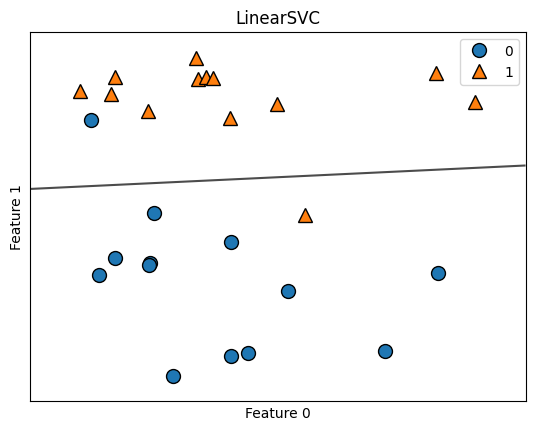

In [42]:
from sklearn.svm import LinearSVC
linear_svc = LinearSVC()
X, y = mglearn.datasets.make_forge()
clf = linear_svc.fit(X, y)
mglearn.plots.plot_2d_separator(clf, X, fill=False, eps=0.5,alpha=.7)
mglearn.discrete_scatter(X[:, 0], X[:, 1], y)
plt.title(clf.__class__.__name__)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.legend()

SVCにおけるハイパーパラメータCを変えてみる

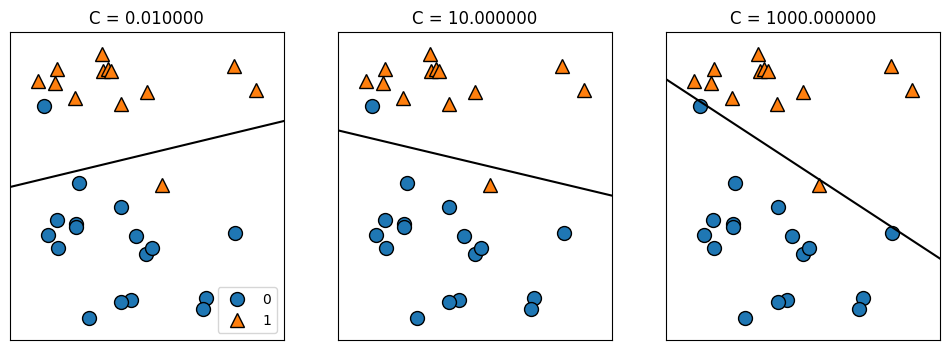

In [43]:
mglearn.plots.plot_linear_svc_regularization()

右側ほどすべての点を正しく分類することを重視するあまり、全体を捉えられていない\
おそらく過剰適合している

以下に示すように、線形分離が不可能な例も存在する

Text(0, 0.5, 'Feature 1')

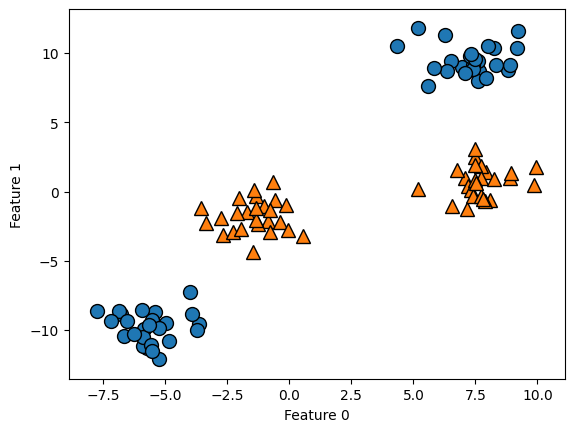

In [44]:
from sklearn.datasets import make_blobs
X, y = make_blobs(centers=4, random_state=8)
y = y % 2
mglearn.discrete_scatter(X[:, 0], X[:, 1], y)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

Text(0, 0.5, 'Feature 1')

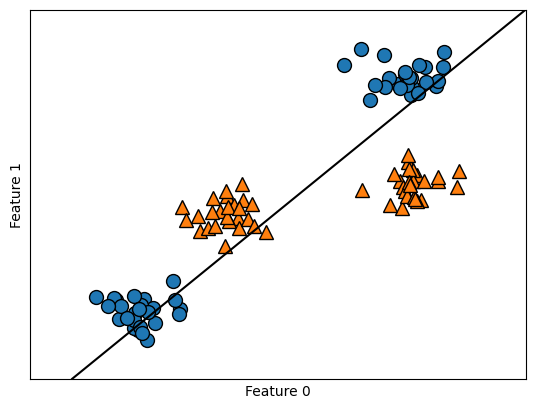

In [45]:
from sklearn.svm import LinearSVC
linear_svm = LinearSVC().fit(X, y)
mglearn.plots.plot_2d_separator(linear_svm, X)
mglearn.discrete_scatter(X[:, 0], X[:, 1], y)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

そこで、入力特徴量を拡張する\
例えば、２番目の特徴量の２乗を新たな特徴量とする

In [46]:
# add the squared second feature
X_new = np.hstack([X, X[:, 1:] ** 2])
from mpl_toolkits.mplot3d import Axes3D, axes3d
figure = plt.figure()
# visualize in 3D
ax = Axes3D(figure, elev=-152, azim=-26)
# plot first all the points with y==0, then all with y == 1
mask = y == 0
ax.scatter(X_new[mask, 0], X_new[mask, 1], X_new[mask, 2], c='b',
           cmap=mglearn.cm2, s=60, edgecolor='k')
ax.scatter(X_new[~mask, 0], X_new[~mask, 1], X_new[~mask, 2], c='r', marker='^',
           cmap=mglearn.cm2, s=60, edgecolor='k')
ax.set_xlabel("feature0")
ax.set_ylabel("feature1")
ax.set_zlabel("feature1 ** 2")

/tmp/ipykernel_1484/1872417744.py:9: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(X_new[mask, 0], X_new[mask, 1], X_new[mask, 2], c='b',
/tmp/ipykernel_1484/1872417744.py:11: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(X_new[~mask, 0], X_new[~mask, 1], X_new[~mask, 2], c='r', marker='^',


Text(0.5, 0, 'feature1 ** 2')

<Figure size 640x480 with 0 Axes>

この拡張されたデータセットに対して線形モデルを適用する

In [47]:
linear_svm_3d = LinearSVC().fit(X_new, y)
coef, intercept = linear_svm_3d.coef_.ravel(), linear_svm_3d.intercept_
# show linear decision boundary
figure = plt.figure()
ax = Axes3D(figure, elev=-152, azim=-26)
xx = np.linspace(X_new[:, 0].min() - 2, X_new[:, 0].max() + 2, 50)
yy = np.linspace(X_new[:, 1].min() - 2, X_new[:, 1].max() + 2, 50)
XX, YY = np.meshgrid(xx, yy)
ZZ = (coef[0] * XX + coef[1] * YY + intercept) / -coef[2]
ax.plot_surface(XX, YY, ZZ, rstride=8, cstride=8, alpha=0.3)
ax.scatter(X_new[mask, 0], X_new[mask, 1], X_new[mask, 2], c='b',
           cmap=mglearn.cm2, s=60, edgecolor='k')
ax.scatter(X_new[~mask, 0], X_new[~mask, 1], X_new[~mask, 2], c='r', marker='^',
           cmap=mglearn.cm2, s=60, edgecolor='k')
ax.set_xlabel("feature0")
ax.set_ylabel("feature1")
ax.set_zlabel("feature1 ** 2")

/tmp/ipykernel_1484/3573654654.py:11: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(X_new[mask, 0], X_new[mask, 1], X_new[mask, 2], c='b',
/tmp/ipykernel_1484/3573654654.py:13: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(X_new[~mask, 0], X_new[~mask, 1], X_new[~mask, 2], c='r', marker='^',


Text(0.5, 0, 'feature1 ** 2')

<Figure size 640x480 with 0 Axes>

これを元の空間で見ると、決定境界が直線から曲線になっていることが分かる

Text(0, 0.5, 'Feature 1')

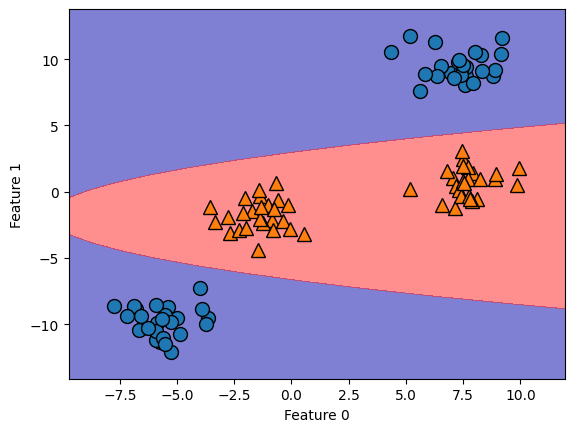

In [48]:
ZZ = YY ** 2
dec = linear_svm_3d.decision_function(np.c_[XX.ravel(), YY.ravel(), ZZ.ravel()])
plt.contourf(XX, YY, dec.reshape(XX.shape), levels=[dec.min(), 0, dec.max()],
             cmap=mglearn.cm2, alpha=0.5)
mglearn.discrete_scatter(X[:, 0], X[:, 1], y)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

以上、カーネルトリックの効果を確認した

ここで、多項式カーネルやガウシアンカーネル(RBFカーネルとも呼ばれる)があることは述べたが、forgeデータセットに対してRBFカーネルを用いたSVMによる決定の様子を見てみる

Text(0, 0.5, 'Feature 1')

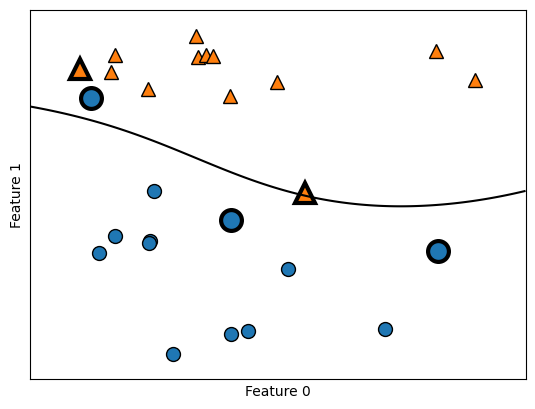

In [49]:
from sklearn.svm import SVC
X, y = mglearn.tools.make_handcrafted_dataset()
svm = SVC(kernel='rbf', C=10, gamma=0.1).fit(X, y)
mglearn.plots.plot_2d_separator(svm, X, eps=.5)
mglearn.discrete_scatter(X[:, 0], X[:, 1], y)
# plot support vectors
sv = svm.support_vectors_
# class labels of support vectors are given by the sign of the dual coefficients
sv_labels = svm.dual_coef_.ravel() > 0
mglearn.discrete_scatter(sv[:, 0], sv[:, 1], sv_labels, s=15, markeredgewidth=3)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

この場合、SVMによる境界は非常になめらかで非線形である\
ここでは、Cとgammaの2つのパラメータを調整している

gammaパラメータはガウシアンカーネルの幅を調整する（点が近いということを意味するスケールを決定する）\
Cパラメータは正則化パラメータで、個々のデータポイントの重要度を制限する\
これらを変化させる

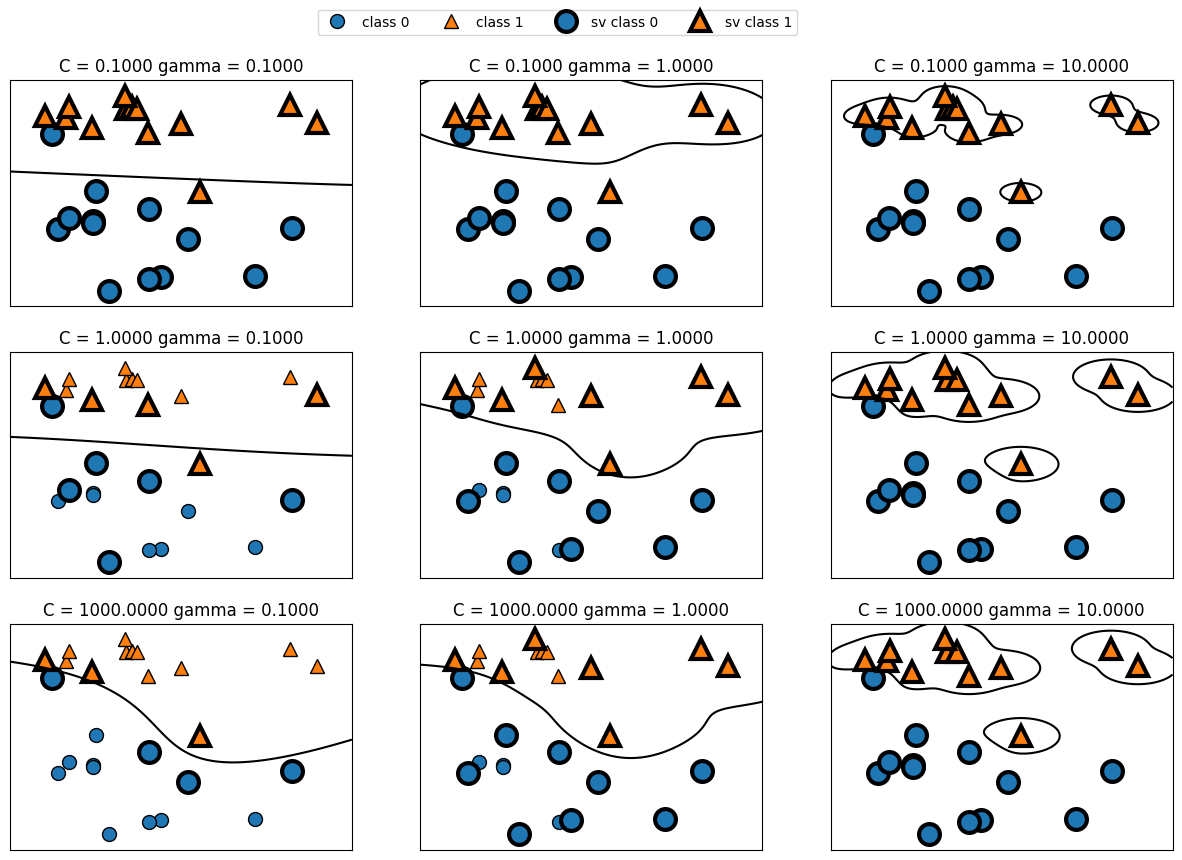

In [50]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, C in zip(axes, [-1, 0, 3]):
  for a, gamma in zip(ax, range(-1, 2)):
    mglearn.plots.plot_svm(log_C=C, log_gamma=gamma, ax=a)
axes[0, 0].legend(["class 0", "class 1", "sv class 0", "sv class 1"],
                  ncol=4, loc=(.9, 1.2))

gammaが小さいとカーネルの直径が大きくなり、多くの点を近いと判断する\
Cを大きくすると、個々のデータポイントが決定境界に強い影響を与えるようになる

## ニューラルネットワーク

ニューラルネットワークが近年「ディープラーニング」という名前で注目を集めている\
ここでは、比較的簡単な多層パーセプトロン（Multilayer Perceptron：MLP）によるクラス分類についてのみ取り扱う

線形回帰では、入力特徴量の重み付き和によって予測を行っていた\
MLPでは、重み付けが繰り返し行われる\
中間処理ステップである隠れユニットの計算で重み付き和が行われ、この隠れユニットの値に対して重み付き和が行われて、最後の結果が算出される

two_moonsデータセットに対してMLPが動く様子を見てみる

Text(0, 0.5, 'Feature 1')

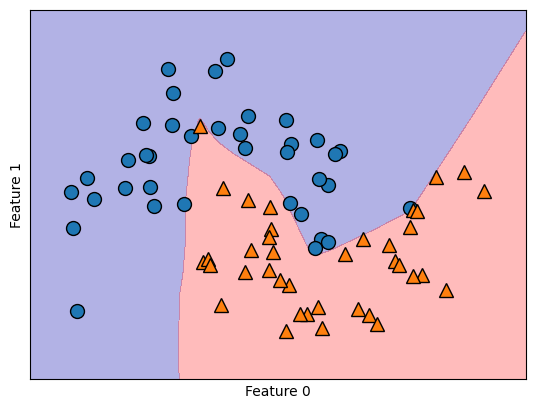

In [51]:
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=100, noise=0.25, random_state=3)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)
mlp = MLPClassifier(solver='lbfgs', random_state=0).fit(X_train, y_train)
mglearn.plots.plot_2d_separator(mlp, X_train, fill=True, alpha=.3)
mglearn.discrete_scatter(X_train[:, 0], X_train[:, 1], y_train)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

これは、隠れユニットの数を100（デフォルト）としているが、この小さいデータセットに対しては大きすぎるため、隠れユニット数を10としてモデルの複雑さを減らす

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Text(0, 0.5, 'Feature 1')

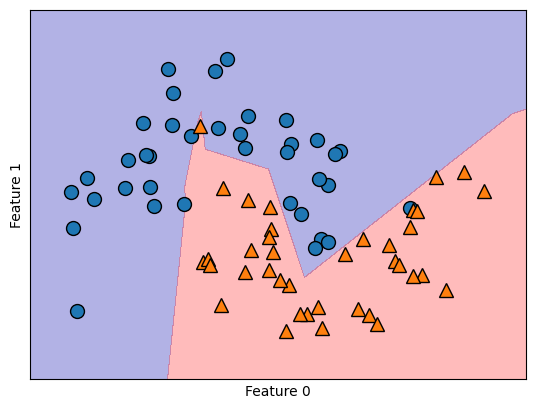

In [52]:
mlp = MLPClassifier(solver='lbfgs', random_state=0, hidden_layer_sizes=[10])
mlp.fit(X_train, y_train)
mglearn.plots.plot_2d_separator(mlp, X_train, fill=True, alpha=.3)
mglearn.discrete_scatter(X_train[:, 0], X_train[:, 1], y_train)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

ニューラルネットワークの複雑さは、隠れ層の数、隠れ層のユニットの数、重みを0に近づける(正則化)などによって制御できる\
正則化の強さはパラメータalphaで決定される\
10ユニットもしくは100ユニットの2層の隠れ層を持つニューラルネットをtwo_moonsに適用した場合のパラメータalphaの効果を以下に示す

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


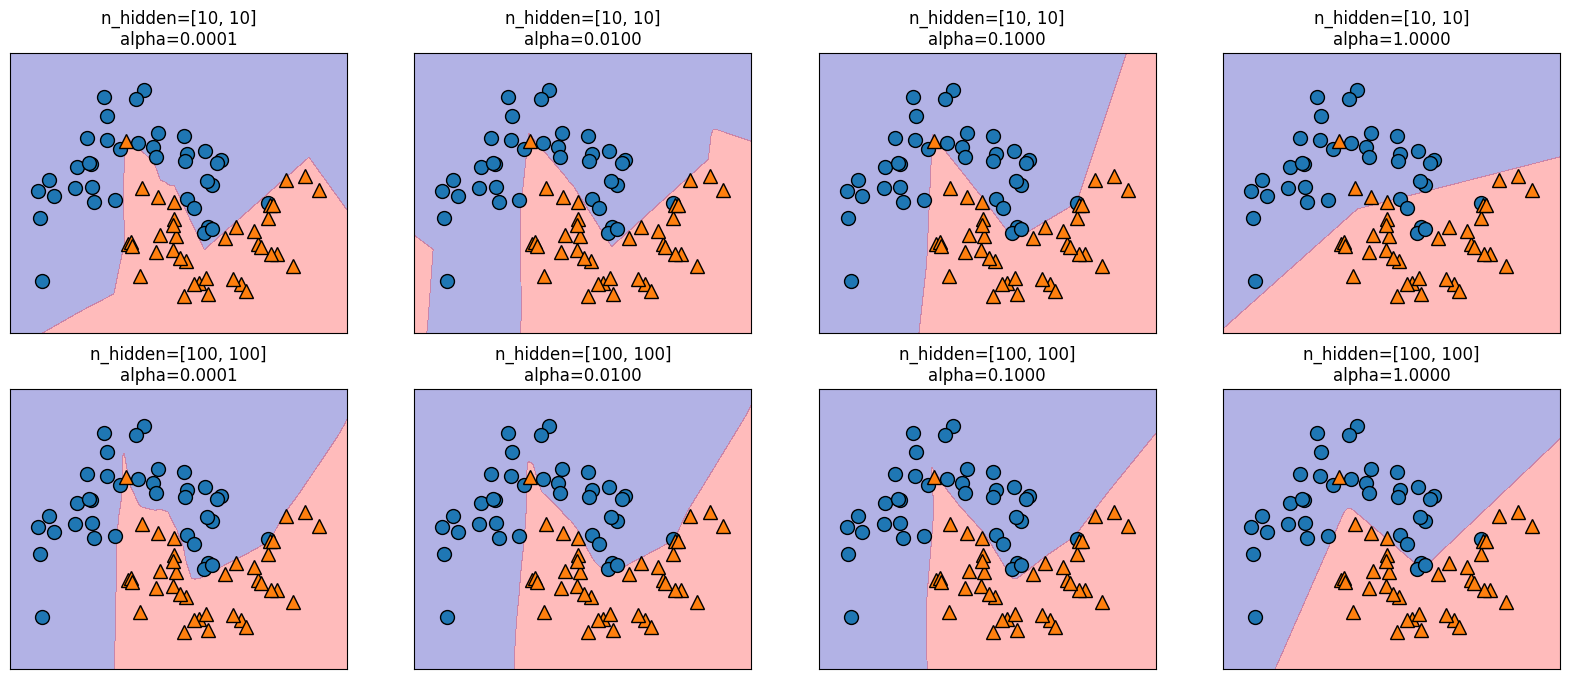

In [53]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for axx, n_hidden_nodes in zip(axes, [10, 100]):
  for ax, alpha in zip(axx, [0.0001, 0.01, 0.1, 1]):
    mlp = MLPClassifier(solver='lbfgs', random_state=0, hidden_layer_sizes=[n_hidden_nodes, n_hidden_nodes], alpha=alpha)
    mlp.fit(X_train, y_train)
    mglearn.plots.plot_2d_separator(mlp, X_train, fill=True, alpha=.3, ax=ax)
    mglearn.discrete_scatter(X_train[:, 0], X_train[:, 1], y_train, ax=ax)
    ax.set_title("n_hidden=[{}, {}]\nalpha={:.4f}".format(n_hidden_nodes, n_hidden_nodes, alpha))

## ナイーブベイズ

ナイーブベイズ（Naive Bayes）は、ベイズの定理（Bayes' theorem）をそのまま分類に用いる確率的なモデルである

特徴量 $x = (x_1, \dots, x_n)$ が観測されたとき、クラス $y$ である確率はベイズの定理により次のように書ける

$$P(y \mid x) = \frac{P(y)\,P(x \mid y)}{P(x)}$$

- $P(y)$ は事前確率で、訓練データに占める各クラスの割合から求まる
- $P(x)$ はどのクラスでも共通なので、クラスを比べるだけなら無視できる
- 問題は $P(x \mid y)$ である
  - $n$ 個の特徴量の組み合わせすべてについて確率を推定することになり、必要なデータ量が特徴量の数に対して指数的に増える

そこで、**クラスが決まれば各特徴量は互いに独立である**（条件付き独立）と仮定する

$$P(x \mid y) = \prod_{i=1}^{n} P(x_i \mid y) \qquad \text{したがって} \qquad \hat{y} = \arg\max_y \; P(y) \prod_{i=1}^{n} P(x_i \mid y)$$

<img src="https://class.west.sd.keio.ac.jp/dataai/text/nbayes-independence.png" width=700>

- 上の図は、仮定の有無で、クラスごとに推定する確率の数がどう変わるかを示している
  - 仮定なしでは特徴量の値の組み合わせごとに確率が必要になるが、仮定を置くと特徴量ごとに別々に求めればよい
- 特徴量を1つずつ別々に見て、$P(x_i \mid y)$ を推定すれば済む（この $P(x_i \mid y)$ を尤度（likelihood）と呼ぶ）
- 現実のデータでは特徴量どうしに相関があるため、この仮定はほぼ成り立たない
  - これが「ナイーブ（単純素朴）」と呼ばれる理由である
- それでも実用になる理由は2つある
  - 分類に必要なのは「どのクラスの値が最大か」だけであり、確率の値そのものが不正確でも、順位が正しければ正解する[Domingos & Pazzani, 1997]
  - 推定するパラメータが少ないため、少ない訓練データでも推定が安定し、過剰適合しにくい

予測の計算の流れを図にすると次のようになる

<img src="https://class.west.sd.keio.ac.jp/dataai/text/nbayes-posterior-flow.png" width=750>

- クラスごとに、事前確率と各特徴量の $P(x_i \mid y)$ をすべて掛け合わせ、その値が大きい方のクラスを予測結果とする

$P(x_i \mid y)$ にどの分布を仮定するかで種類が分かれる
- `GaussianNB` …連続値の特徴量に正規分布を仮定する
- `MultinomialNB` …単語の出現回数のようなカウントデータに多項分布を仮定する
- `BernoulliNB` …0か1かの2値の特徴量に用いる

実際の計算では、確率の積ではなく**対数の和**を用いる

$$\hat{y} = \arg\max_y \left[ \log P(y) + \sum_{i=1}^{n} \log P(x_i \mid y) \right]$$

- 1より小さい数を何百個も掛けると、値が小さくなりすぎて、コンピュータの浮動小数点数では0になってしまう（アンダーフロー）
  - すべてのクラスの値が0になると、どのクラスが最大かを比べられない
- 対数は単調増加なので、対数をとっても大小関係は変わらない
- 積が和になるので、桁あふれの心配がなくなる
- scikit-learnのナイーブベイズも内部では対数で計算しており、`predict_log_proba`で対数確率を取り出せる

In [ ]:
# 確率の積と対数の和を比べる
p = np.full(200, 0.01)  # 0.01という確率を200個用意する（200個の特徴量に相当）
print('Product of probabilities: {}'.format(np.prod(p)))
print('Sum of log probabilities: {:.1f}'.format(np.sum(np.log(p))))

cancerデータセットに`GaussianNB`を適用してみる
- 学習は、クラスごとに各特徴量の平均と分散を計算するだけである
- ランダムフォレストの例題と同じ分割を用いるので、精度を比べるとよい

In [ ]:
# GaussianNBをcancerデータセットに適用する
from sklearn.naive_bayes import GaussianNB
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, stratify=cancer.target, random_state=0)
gnb = GaussianNB()
gnb.fit(X_train, y_train)
print('Accuracy on training set: {:.3f}'.format(gnb.score(X_train, y_train)))
print('Accuracy on test set: {:.3f}'.format(gnb.score(X_test, y_test)))

訓練セットに対する精度は95％、テストセットに対する精度は92％程度となった
- 同じ分割でのランダムフォレスト（100個の決定木）のテストセットに対する精度は94％程度であり、それには及ばない
- 一方で、調整するハイパーパラメータもなく、一瞬で学習が終わる
- 訓練セットとテストセットの精度の差が小さく、過剰適合は起きにくい

ナイーブベイズは`predict_proba`で確率も出力できるので、その値を確認する

In [ ]:
# 予測確率の分布を確認する
proba = gnb.predict_proba(X_test)[:, 1]
extreme = (proba < 0.01) | (proba > 0.99)
wrong = gnb.predict(X_test) != y_test
print('Samples with probability below 0.01 or above 0.99: {} / {}'.format(extreme.sum(), len(proba)))
print('Misclassified samples: {}'.format(wrong.sum()))
print('Misclassified with such extreme probability: {}'.format((wrong & extreme).sum()))

ほとんどのサンプルで、確率が0か1に極端に寄っている
- 誤分類したサンプルの多くでも、99％以上の確信をもって間違えている
- cancerデータセットの特徴量（半径、周囲長、面積など）は互いに強く相関している
  - 独立と仮定すると、同じ証拠を何度も掛け合わせることになり、確信が過剰になる
- このように、出力される確率が実際の正解率と合っていないことを、確率の**校正（calibration）**が悪いという
  - 分類結果は使えても、確率の値をそのまま信用してはならない

校正の良し悪しを、ランダムフォレストと比べて確かめる
- テストセットの143件だけでは少ないので、`cross_val_predict`を用いる
  - データを5分割し、各サンプルについて「そのサンプルを学習に使っていないモデル」の予測確率を得る
  - これにより全569件を評価に使える
- 予測確率を0.2刻みの5つの区間に分け、区間ごとに次の2つを比べる
  - predicted …その区間に入ったサンプルの予測確率の平均
  - actual …その区間のサンプルのうち、実際にクラス1（良性）であった割合
  - 校正がよいモデルでは、この2つがほぼ一致する
  - 横軸にpredicted、縦軸にactualをとって描いた図を信頼性曲線（reliability curve）と呼ぶ（`sklearn.calibration.calibration_curve`で計算できる）
- **ブライアスコア（Brier score）**も計算する
  - 予測確率と正解（0か1）の差の2乗の平均で、小さいほどよい

In [ ]:
# GaussianNBとランダムフォレストの予測確率の校正を比べる
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import brier_score_loss
from sklearn.ensemble import RandomForestClassifier
models = {'GaussianNB': GaussianNB(), 'RandomForest': RandomForestClassifier(n_estimators=100, random_state=0)}
proba_cv = {}
for name, model in models.items():
  # 各サンプルについて、そのサンプルを学習に使っていないモデルによるクラス1の予測確率を得る
  proba_cv[name] = cross_val_predict(model, cancer.data, cancer.target, cv=5, method='predict_proba')[:, 1]
  print('{}  Brier score: {:.3f}'.format(name, brier_score_loss(cancer.target, proba_cv[name])))
  bin_index = np.minimum((proba_cv[name] * 5).astype(int), 4)  # 0.2刻みの区間の番号（0〜4）
  for i in range(5):
    in_bin = bin_index == i
    if in_bin.sum() > 0:
      print('  bin {:.1f}-{:.1f}: {:3d} samples, predicted = {:.3f}, actual = {:.3f}'.format(0.2 * i, 0.2 * (i + 1), in_bin.sum(), proba_cv[name][in_bin].mean(), cancer.target[in_bin].mean()))

# 予測確率の分布を描く
plt.hist(list(proba_cv.values()), bins=10, range=(0, 1), label=list(proba_cv.keys()))
plt.xlabel('Predicted probability of class 1')
plt.ylabel('Number of samples')
plt.legend()

`GaussianNB`の予測確率は、両端の区間にほぼすべてが集中している
- 0.8〜1.0の区間では、平均して99.8％の確信で良性と予測しているが、実際に良性であったのは94.2％である
- 0.0〜0.2の区間では、良性の確率を平均0.2％と予測しているが、実際には4.6％が良性である
  - 「ほぼ確実」と言いながら、20回に1回程度は外している
- 中間の区間にはサンプルが数件しかなく、actualの値は当てにならない
  - 信頼性曲線を見るときは、各区間のサンプル数も必ず確認する
- ランダムフォレストは、自信のないサンプルには中間の確率を出しており、両端の区間でpredictedとactualがよく合っている
  - ランダムフォレストも完全ではない（0.6〜0.8の区間ではずれがある）が、ブライアスコアは`GaussianNB`の0.056に対して0.031と小さい
- 確率の値そのものを使いたい場合（リスクの見積もり、しきい値の調整など）は、`CalibratedClassifierCV`などで校正し直すか、別のモデルを用いる

確信が過剰になる原因が特徴量どうしの相関であることを、小さな実験で確かめる
- cancerデータセットの特徴量の1つ（perimeter error）をそのまま複製して、特徴量として追加する
  - 複製した特徴量は元の特徴量と完全に相関しており、新しい情報は何も増えていない
  - 情報が増えていないのだから、本来は精度が変わらないはずである

In [ ]:
# 同じ特徴量を複製して、完全に相関した特徴量を人工的に増やす
col = [list(cancer.feature_names).index('perimeter error')]
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, stratify=cancer.target, random_state=0)
for n_copies in [0, 5, 20, 50]:
  # 元の30個の特徴量の右に、同じ列をn_copies個並べる
  X_train_dup = np.hstack([X_train] + [X_train[:, col]] * n_copies)
  X_test_dup = np.hstack([X_test] + [X_test[:, col]] * n_copies)
  gnb_dup = GaussianNB().fit(X_train_dup, y_train)
  forest_dup = RandomForestClassifier(n_estimators=100, random_state=0).fit(X_train_dup, y_train)
  print('copies = {:2d}  GaussianNB: {:.3f}  RandomForest: {:.3f}'.format(n_copies, gnb_dup.score(X_test_dup, y_test), forest_dup.score(X_test_dup, y_test)))

`GaussianNB`は、複製を増やすほど精度が下がっていく
- 複製が50個のとき、テストセットに対する精度は0.923から0.832まで下がった
- 同じ特徴量をn個複製すると、その特徴量の $P(x_i \mid y)$ がn+1回掛けられる
  - 1つの証拠を何度も数えることになり、その特徴量だけで結論が決まってしまう

<img src="https://class.west.sd.keio.ac.jp/dataai/text/nbayes-double-count.png" width=700>

- 上の図は、ある特徴量の尤度がクラスAで3倍大きい場合の例である
  - その特徴量だけならクラスAの確率は75％であるが、複製を2個加えると尤度の比が27対1になり、確率は約96％まで上がる
  - 新しい情報は何も増えていないのに、確信だけが強くなっている
- ランダムフォレストの精度は0.94〜0.95程度のままで、ほとんど影響を受けない
  - 決定木は分割のたびに特徴量を1つ選ぶだけなので、同じ特徴量が何個あっても同じ分割になる
- どの特徴量を複製するかで下がり方は異なり、ほとんど変わらない特徴量もある
- ナイーブベイズを用いるときは、重複した特徴量や強く相関した特徴量を事前に取り除くとよい

次に、`MultinomialNB`で短い文書を分類してみる
- 文書を単語の出現回数のベクトルに変換する（`CountVectorizer`）
- クラス $y$ の文書に単語 $i$ が出現する確率を、次の式で推定する

$$P(x_i \mid y) = \frac{N_{yi} + \alpha}{N_y + \alpha n}$$

- $N_{yi}$ はクラス $y$ の訓練文書における単語 $i$ の出現回数、$N_y$ はクラス $y$ の総単語数、$n$ は語彙数である
- $\alpha$ を加える操作を**ラプラス平滑化（Laplace smoothing）**と呼ぶ
  - $\alpha = 0$ だと、そのクラスの訓練文書に一度も現れなかった単語の確率が0になる
  - 確率は掛け算なので、0が1つでもあると、他の単語が何であってもそのクラスの確率が0になってしまう
  - すべての単語が $\alpha$ 回ずつ余分に出現したとみなすことで、これを防ぐ（デフォルトは `alpha=1.0`）

In [ ]:
# MultinomialNBによる短い文書の分類
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
train_texts = [
    'win a free prize now',
    'free money click now',
    'claim your free prize today',
    'cheap loans win money',
    'meeting at noon today',
    'please review the report',
    'lunch with the team tomorrow',
    'the report is due tomorrow',
]
train_labels = ['spam', 'spam', 'spam', 'spam', 'ham', 'ham', 'ham', 'ham']
test_texts = ['free prize money', 'review the meeting report', 'free lunch with the team']

vect = CountVectorizer()
X_text = vect.fit_transform(train_texts)  # 行が文書、列が単語、値が出現回数
print('Vocabulary size: {}'.format(len(vect.vocabulary_)))

# 平滑化あり(alpha=1.0)と、ほぼなし(alpha=1e-10)を比べる
for alpha in [1.0, 1e-10]:
  mnb = MultinomialNB(alpha=alpha)
  mnb.fit(X_text, train_labels)
  print('alpha = {}'.format(alpha))
  for text, label, p in zip(test_texts, mnb.predict(vect.transform(test_texts)), mnb.predict_proba(vect.transform(test_texts))):
    print('  {:28s} -> {:4s}  P(ham) = {:.3f}, P(spam) = {:.3f}'.format(text, label, p[0], p[1]))

迷惑メール（spam）と通常のメール（ham）を、単語の頻度だけで分類できている
- 3つ目の文書「free lunch with the team」は、spamに多い「free」とhamに多い「lunch」「team」が混ざっている
  - `alpha=1.0` では、hamと判定しつつもspamの確率を0.12程度残している
  - `alpha=1e-10` では、「lunch」などがspamの訓練文書に一度も現れないため、spamの確率がほぼ0になる
  - 訓練データにたまたま現れなかった、というだけで可能性を完全に否定してしまうのが、平滑化なしの問題である

ナイーブベイズの特徴をまとめる
- 長所
  - 学習も予測も非常に高速で、特徴量の数が多い（数万語の語彙など）データにも適用できる
  - 少ない訓練データでもそれなりに動く
  - 確率が出力され、どの特徴量がどちらのクラスに効いたかも追いやすい
  - 手間がかからないので、他のモデルと比べるためのベースラインとしてよく用いられる
- 短所
  - 独立性の仮定のため、特徴量どうしの組み合わせに意味がある問題は表現できない
  - 相関の強い特徴量が多いと確率が極端になり、校正が悪い
  - 十分なデータがあれば、ランダムフォレストなどに精度で及ばないことが多い

# 教師なし学習

## 教師なし学習の種類

- 教師なし変換
 - 次元削減
- クラスタリングアルゴリズム

## k-meansクラスタリング
最も単純なクラスタリングアルゴリズム  
- 個々のデータポイントを最寄りのクラスタ重心に割り当てる
- 個々のクラスタ重心をその点に割り当てられたデータポイントの平均に設定する

というステップを繰り返し、割り当てが変化しなくなったらアルゴリズムは終了する

合成データセットにこれを適用してみる

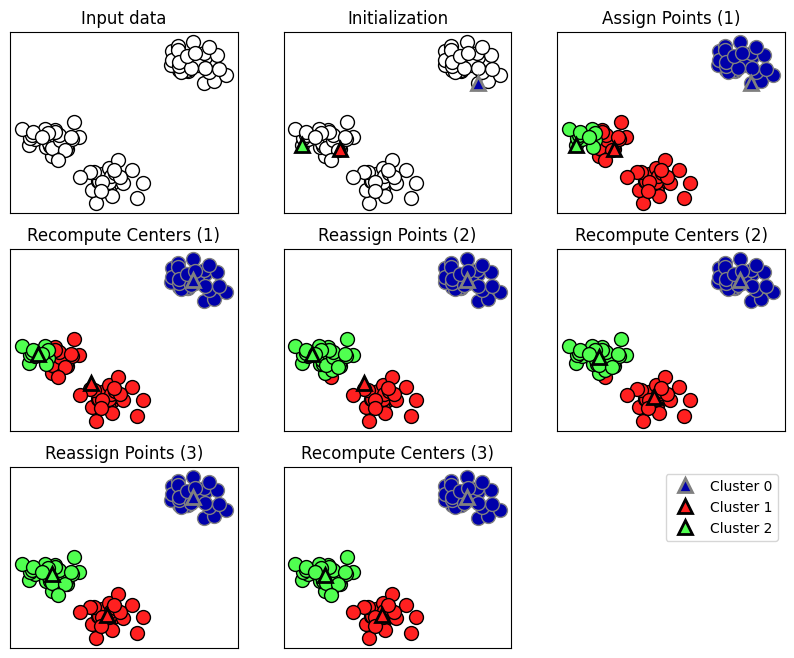

In [54]:
mglearn.plots.plot_kmeans_algorithm()

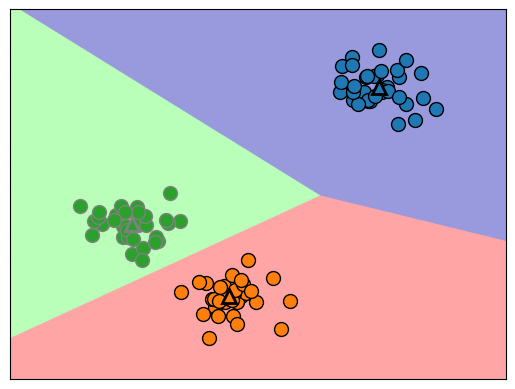

In [55]:
mglearn.plots.plot_kmeans_boundaries()

In [56]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
# generate synthetic two-dimensional data
X, y = make_blobs(random_state=1)
# build the clustering model
kmeans = KMeans(n_clusters=3)
kmeans.fit(X)

KMeans(n_clusters=3)

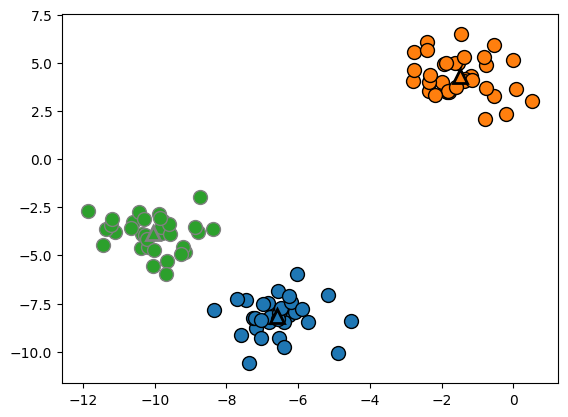

In [57]:
mglearn.discrete_scatter(X[:, 0], X[:, 1], kmeans.labels_, markers='o')
mglearn.discrete_scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], [0, 1, 2], markers='^', markeredgewidth=2)

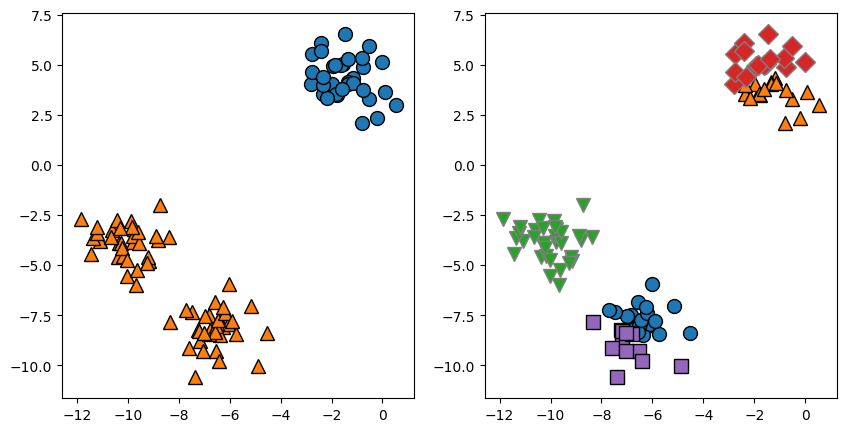

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
# using two cluster centers:
kmeans = KMeans(n_clusters=2)
kmeans.fit(X)
assignments = kmeans.labels_
mglearn.discrete_scatter(X[:, 0], X[:, 1], assignments, ax=axes[0])
# using five cluster centers:
kmeans = KMeans(n_clusters=5)
kmeans.fit(X)
assignments = kmeans.labels_
mglearn.discrete_scatter(X[:, 0], X[:, 1], assignments, ax=axes[1])

以下は上手くいかない例である

Text(0, 0.5, 'Feature 1')

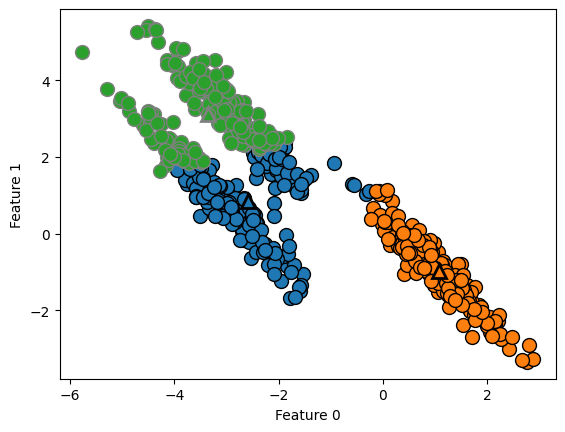

In [59]:
# generate some random cluster data
X, y = make_blobs(random_state=170, n_samples=600)
rng = np.random.RandomState(74)
# transform the data to be stretched
transformation = rng.normal(size=(2, 2))
X = np.dot(X, transformation)
# cluster the data into three clusters
kmeans = KMeans(n_clusters=3)
kmeans.fit(X)
y_pred = kmeans.predict(X)
# plot the cluster assignments and cluster centers
mglearn.discrete_scatter(X[:, 0], X[:, 1], kmeans.labels_, markers='o')
mglearn.discrete_scatter(
  kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], [0, 1, 2],
  markers='^', markeredgewidth=2)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

Text(0, 0.5, 'Feature 1')

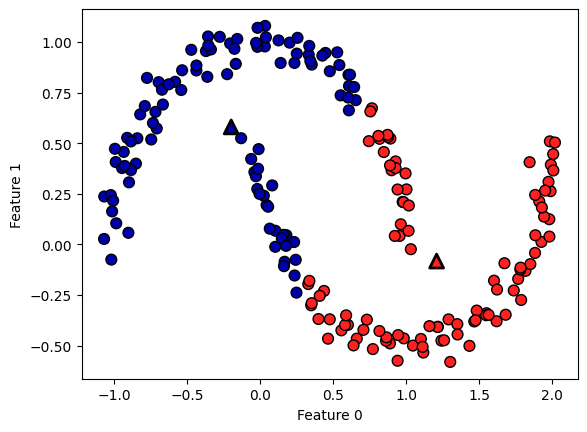

In [60]:
# generate synthetic two_moons data (with less noise this time)
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=200, noise=0.05, random_state=0)
# cluster the data into two clusters
kmeans = KMeans(n_clusters=2)
kmeans.fit(X)
y_pred = kmeans.predict(X)
# plot the cluster assignments and cluster centers
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap=mglearn.cm2, s=60, edgecolor='k')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            marker='^', c=[mglearn.cm2(0), mglearn.cm2(1)], s=100, linewidth=2,
            edgecolor='k')
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

このように、k-meansはクラスタが丸くない場合や複雑な形状の場合にはうまく機能しない

## 教師なし学習の難しさ
教師なし学習の難しさは、アルゴリズムが学習したことの有用性の評価にある\
教師なし学習で与えるデータはラベルが分かっていないデータであるため、出力が正解かどうかを判断することができず、結果が人間が求めているものとなっているかを人間が確かめるしかない

参考として、次のある学生のスライドを紹介しておく

[スライドはこちら](https://www.slideshare.net/ngkry/ss-51045351)

なお、論文になっている

[論文はこちら](https://www.google.com/url?sa=t&rct=j&q=&esrc=s&source=web&cd=&ved=2ahUKEwj8u4PM78PsAhUGM94KHT1IDfIQFjAAegQIBxAC&url=https%3A%2F%2Fipsj.ixsq.nii.ac.jp%2Fej%2Findex.php%3Faction%3Dpages_view_main%26active_action%3Drepository_action_common_download%26item_id%3D176518%26item_no%3D1%26attribute_id%3D1%26file_no%3D1%26page_id%3D13%26block_id%3D8&usg=AOvVaw3iiWXIfl2c_uSq3zhFjb99)

ラベルがなくても、Silhouette係数などでクラスタのまとまりを測る方法はある
- 内部指標が高いことと、現実に意味のある分類であることは別である
- 自己教師あり学習で得た表現は、少量のラベルを用いる下流タスク、検索、転移性能などで評価する


# scikit-learnが提供するモデルについて

チートシートで示したように多くのモデルが実装されている

ここでは、そのなかから、今後も利用する価値が高い、学んでおくことで今後の理解が進むと思われる内容のみ扱った

その他のモデルについては、( https://qiita.com/sugulu_Ogawa_ISID/items/e3fc39f2e552f2355209 )が詳しい
- 書籍「AIエンジニアを目指す人のための機械学習入門 実装しながらアルゴリズムの流れを学ぶ」として出版されている
- なお、現状において重要かというとそういうわけでもなく、特に当該分野の研究者を目指す場合やAIの歴史を学ぶ場合ではない限り、本内容で十分であろう

表形式のデータでも基盤モデルの研究が進んでいる
- **TabPFN**[Hollmann et al., 2025]は、多数の合成データセットで事前学習したTransformerを用いる
  - 対象の訓練例を入力文脈として与え、推論で未知サンプルを予測するin-context learningを利用する
  - 原論文では、主に1万サンプル・500特徴量までのデータを扱う条件で高い性能を報告している
  - その条件での結果を、あらゆる大規模・時系列・分布外の問題での優位性と混同しない
- LightGBM、線形モデル、MLPなどを同じ分割・指標で比較し、精度、学習・推論時間、メモリ、利用条件を確認する
- DNNであれば常に決定木よりよい、という前提で選ばない


# 課題(データの分類)
いつもの通りの提出方法とする

**[課題]**
- 上記のcancerおよびtwo_moonsデータセットについて、ランダムフォレストおよび、既に扱ったLightGBMそれぞれについて分類し、評価しなさい
- 比較は、cancer、two_moonsデータセット100個、two_moonsデータセット300個の3種類、それぞれランダムフォレスト、LightGBMを用いるため、全部で6個の結果を用いて評価する
- その上で、どちらが優れているかを比較しなさい

なお、解答にあたっては次の点に注意しなさい
- 単純な比較が行われ、結果が妥当ではない場合でも特に問題はない
- 本来は、例えば交差検証を行う、何度か試みて平均をとるなどしなければ、論文やきちんとした評価などでは通用しないが、ここでは厳密さは問わない
- コードと結果を示し、最後に、それらを纏めて、単純にランダムフォレストとLightGBMのどちらが優れていると考えられるかだけ記述しなさい

上記で解答が困難な場合は、以下にcancerのランダムフォレストとLightGBMの参考コードを記載する
- このコードはそのまま課題の解答の一部として用いてよい
- このコードを書き替えて、two_moonsの100および300について分類し、その精度を求めれば課題は成立する

- わからない！という場合の多くは各関数の意味が理解できていないのが原因と思われるので、まずはググること
- mglearnのコードは課題では求めておらず不要である
  - 下記余裕がある場合を参照
- テンプレがあれば1から素で書けるようになること
  - これからの課題や試験が太刀打ちできなくなる
  - コードを見てわかる通り、実質データを準備するのに2行、モデルの準備に1行、モデルの構築(学習)に1行、推定に1行、アキュラシーを求めるのに1行なので、ここで根をあげないように
    - 高々6行でできるところに注目し、6行に振り回されないように
    - PyTorchはそうはいきませんので

**(余裕がある場合)**

- 余裕がある人は、答えを使った混同行列やF値、MCCといった評価が行えるので試してみると良い
- 敢えてmglearnのコードを追加しているのは、なぜ〇〇が〇〇でよくないのか？を知るためである
  - 是非その理由を考察してみると良い
  - mglearnを用いればすべてがわかるというわけではない他のツールを駆使して、本質に迫ると良いであろう
  - Kagglerでも大人気、最強といわれるLightGBMだけに頼ることができないことがよくわかるであろう
- LightGBMは、先に示した例が回帰であったように、回帰にも2値・多値分類にも使える万能選手である
  - LightGBMのマニュアルにある、objectiveを調べると良い
- さらに余裕のある人は、LightGBMのランダムフォレストモードを利用してみると良いだろう
  - ランダムフォレストと結果は同じになるだろうか？

In [61]:
!pip install mglearn

## ランダムフォレスト cancer

In [62]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, stratify=cancer.target, random_state=42)
forestc = RandomForestClassifier(n_estimators=6, random_state=2)
forestc.fit(X_train, y_train)
print('Accuracy on training set: {:.3f}'.format(forestc.score(X_train, y_train)))
print('Accuracy on test set: {:.3f}'.format(forestc.score(X_test, y_test)))
x_pred = forestc.predict(X_test) # forestc.score(X_test, y_test)としても一緒、書き下すとこういう意味、答えも一緒
acc_rf_c = (y_test==x_pred).sum()/len(y_test)
acc_rf_c

Accuracy on training set: 1.000
Accuracy on test set: 0.972


np.float64(0.972027972027972)

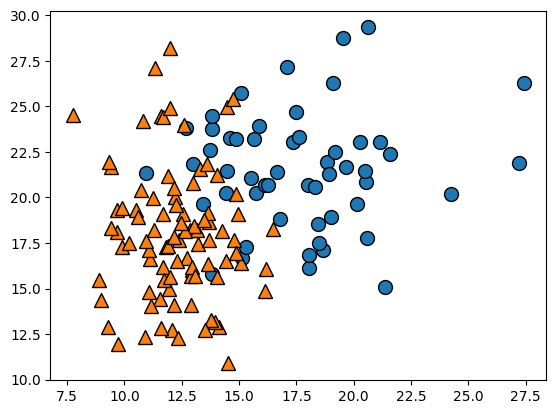

In [63]:
import mglearn
mglearn.discrete_scatter(X_test[:, 0], X_test[:, 1], y_test)

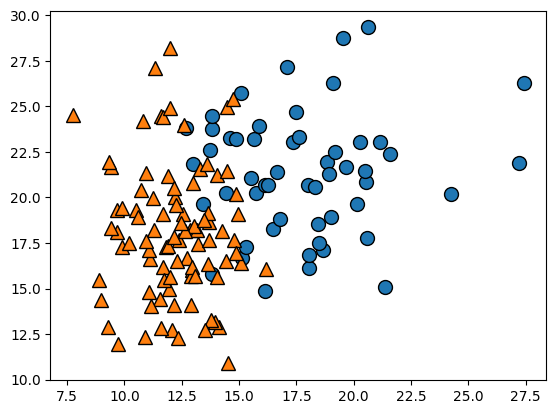

In [64]:
mglearn.discrete_scatter(X_test[:, 0], X_test[:, 1], x_pred)

## LightGBM cancer

以下を実行すると、おそらく、「No further splits with positive gain, best gain: -inf」とwarningが表示されるであろう
 - LightGBMが内部で決定木を成長させてる際、pre-pruning（特徴空間をそれ以上分割しても情報利得が得られず分割を停止する機能）が働いたことを示す
 - 決定木の成長アルゴリズムとして次の2つがあり、一般的にdepth-firstが利用されるのに対してLightGBMはbest-firstを利用する
  - level-wise：同じ深さのノードをまとめて成長させるdepth-firstとは別の概念である
  - best-first (leaf-wise) ：分岐することでより不純度・予測誤差を下げることができる枝から伸ばす
 - 成長順序、停止条件、分岐候補などで結果は変わり、同じ木になるとは限らない

 - 決定木の剪定アルゴリズム、つまり木を無駄に成長させないようにする手法には次の2種類がある
  - pre-pruning：追加で分岐して予測誤差を下げられる時だけ分岐、最適な木を発見できない可能性があるが、post-pruningよりも計算コストが小さい(LightGBMで利用)
  - post-pruning：まず決定木を完全に成長させた後に最も予測誤差を下げる木のサイズを選択

- つまり、最良の分岐を探索する際に、分岐による情報利得が得られない（それ以上分割しても得をしない）ところまできた、ということを意味する


In [65]:
import lightgbm as lgb
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, stratify=cancer.target, random_state=42)
dtrain = lgb.Dataset(X_train, label=y_train)
dtest = lgb.Dataset(X_test, label=y_test)
params={
  'objective': 'binary',
  'random_state': 42,
  'metric': 'binary_logloss'
}
bstc = lgb.train(params, dtrain, num_boost_round=1000,valid_sets=[dtrain, dtest])
print("Best Score:", bstc.best_score["valid_1"]['binary_logloss'])
x_pred = (bstc.predict(X_test)>0.5)
acc_lg_c = (y_test==x_pred).sum()/len(y_test) # こちらは、scoreメソッドが存在しない
acc_lg_c

[LightGBM] [Info] Number of positive: 267, number of negative: 159
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009977 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4266
[LightGBM] [Info] Number of data points in the train set: 426, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.626761 -> initscore=0.518344
[LightGBM] [Info] Start training from score 0.518344
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

np.float64(0.965034965034965)

ここで、
> No further splits with positive gain, best gain: -inf

とWarningが表示された場合は、LightGBMが内部で決定木を成長させている際にpre-pruning（特徴空間をそれ以上分割しても情報利得が得られないので分割を停止する仕組み）が働いたことを示す

min_data_in_leaf などの別のハイパーパラメータを調整する手がかりにすればよいかもしれない
- pruningさせるのとハイパーパラメータで分岐を止めるのとどちらが良いかの判断が必要

もうひとつ、

> Stopped training because there are no more leaves that meet the split requirements


と表示される場合があるが、これはデフォルトの最小サンプル数に対して、それよりも小さな行数となり、分割できないことを表している
- min_data_in_leafのデフォルト値は20である

なお、結果に影響しないと判断し、ここでは無視している

### Accuracyの演算について

ランダムフォレストは、scoreを用いることができた
```
forestc.score(X_test, y_test)
```
この例のLightGBMの `Booster` には、分類器の `score` がない
- scikit-learn互換の `LGBMClassifier` には `score` がある、そこで同じ意味で次のように記述した

```
(y_test==x_pred).sum()/len(y_test)
```
もう一つ、次の記述の方法も取得済みである
- 実行してみよう
- すべて同じ値を出力するので、ランダムフォレストの例で試してみると良いであろう

In [66]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, x_pred)

0.965034965034965

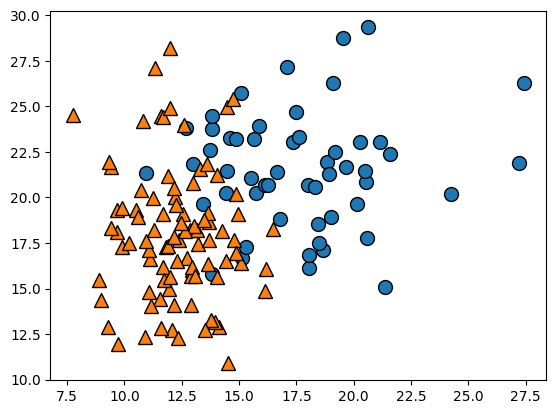

In [67]:
import mglearn
mglearn.discrete_scatter(X_test[:, 0], X_test[:, 1], y_test)

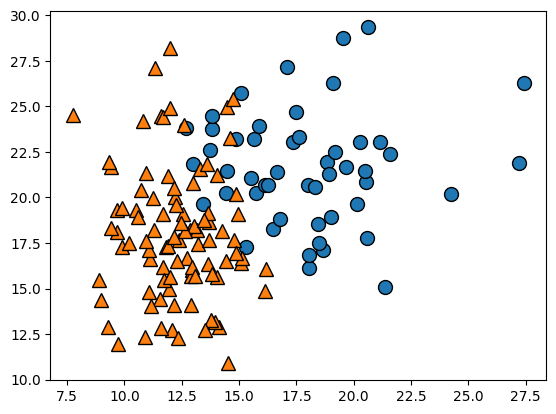

In [68]:
mglearn.discrete_scatter(X_test[:, 0], X_test[:, 1], x_pred)

## 比較のまとめ

In [69]:
print("ランダムフォレスト cancer:", acc_rf_c)
print("LightGBM cancer:", acc_lg_c)

ランダムフォレスト cancer: 0.972027972027972
LightGBM cancer: 0.965034965034965


他の比較も同様に加えること

# 参考文献
- Pedregosa, F. et al. (2011). "scikit-learn: Machine Learning in Python." JMLR
- Müller, A. C. & Guido, S. (2016). "Introduction to Machine Learning with Python." O'Reilly Media
- Ke, G. et al. (2017). "LightGBM: A Highly Efficient Gradient Boosting Decision Tree." NeurIPS 2017

- Hollmann, N. et al. (2025). [Accurate predictions on small data with a tabular foundation model](https://www.nature.com/articles/s41586-024-08328-6). Nature, 637, 319–326
- scikit-learn. [DummyClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html)
- scikit-learn. [Clustering performance evaluation](https://scikit-learn.org/stable/modules/clustering.html#clustering-performance-evaluation)

- Domingos, P. & Pazzani, M. (1997). "On the Optimality of the Simple Bayesian Classifier under Zero-One Loss." Machine Learning, 29, 103–130